## TITANIC SURVIVAL PREDICTION USING REUSABLE ML PIPELINE

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay)

In [3]:
#load Dataset 
df = pd.read_csv("titanic.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [4]:
#Display first five rows

print("\nFirst 5 Rows")
print(df.head())


First 5 Rows
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

In [5]:
#Dataset info
print("\nDataset Information")
print(df.info())


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [6]:
# 5. Dataset Statistics
print("\nStatistical Summary")
print(df.describe())


Statistical Summary
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [7]:
# 6. Check Missing Values
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64



Target Distribution
Survived
0    549
1    342
Name: count, dtype: int64


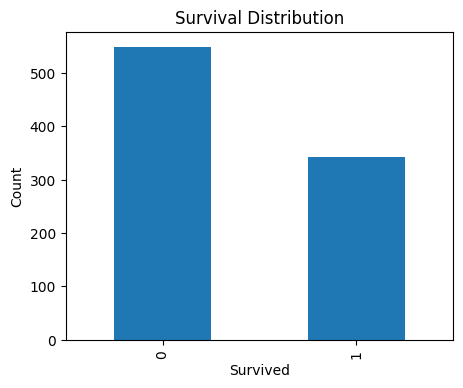

In [8]:
# 7. Target Variable Distribution
print("\nTarget Distribution")
print(df["Survived"].value_counts())

plt.figure(figsize=(5,4))
df["Survived"].value_counts().plot(kind="bar")
plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

In [9]:
# 8. Feature Selection
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [10]:
# Drop unnecessary columns
X = X.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

In [11]:
# 9. Define Numerical &    Categorical Columns
numeric_features = [
    "Age",
    "Fare",
    "SibSp",
    "Parch"
]

categorical_features = [
    "Pclass",
    "Sex",
    "Embarked"
]

In [12]:
# 10. Numerical Pipeline
numeric_pipeline = Pipeline(steps=[

    ("imputer",
     SimpleImputer(strategy="median")),

    ("scaler",
     StandardScaler())

])

In [13]:
# 11. Categorical Pipeline
categorical_pipeline = Pipeline(steps=[

    ("imputer",
     SimpleImputer(strategy="most_frequent")),

    ("encoder",
     OneHotEncoder(handle_unknown="ignore"))

])

In [14]:
# 12. Column Transformer
preprocessor = ColumnTransformer(

    transformers=[

        ("num",
         numeric_pipeline,
         numeric_features),

        ("cat",
         categorical_pipeline,
         categorical_features)

    ]

)

In [16]:
# 13. Final Reusable ML Pipeline
model_pipeline = Pipeline(steps=[

    ("preprocessor",
     preprocessor),

    ("classifier",
     RandomForestClassifier(
         random_state=42
     ))

])


In [18]:
# 14. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,
)

In [19]:
# 15. Train Model
model_pipeline.fit(X_train, y_train)

print("\nModel Training Completed!")


Model Training Completed!


In [20]:
# 16. Prediction
y_pred = model_pipeline.predict(X_test)

In [21]:
# 17. Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy")

print(round(accuracy*100,2),"%")


Accuracy
82.68 %


In [22]:
# 18. Classification Report
print("\nClassification Report")

print(classification_report(
    y_test,
    y_pred
))


Classification Report
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.76      0.78        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179




Confusion Matrix
[[92 13]
 [18 56]]


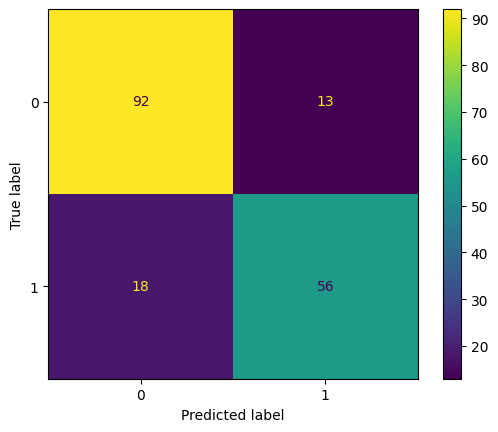

In [23]:
# 19. Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix")

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

In [24]:
# 20. Feature Importance
feature_names = model_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = model_pipeline.named_steps[
    "classifier"
].feature_importances_

feature_importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance": importance

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 Important Features")

print(feature_importance.head(10))


Top 10 Important Features
            Feature  Importance
1         num__Fare    0.251253
0          num__Age    0.249880
7   cat__Sex_female    0.145674
8     cat__Sex_male    0.140728
6     cat__Pclass_3    0.048256
2        num__SibSp    0.045931
3        num__Parch    0.037883
4     cat__Pclass_1    0.023363
5     cat__Pclass_2    0.021108
11  cat__Embarked_S    0.015279


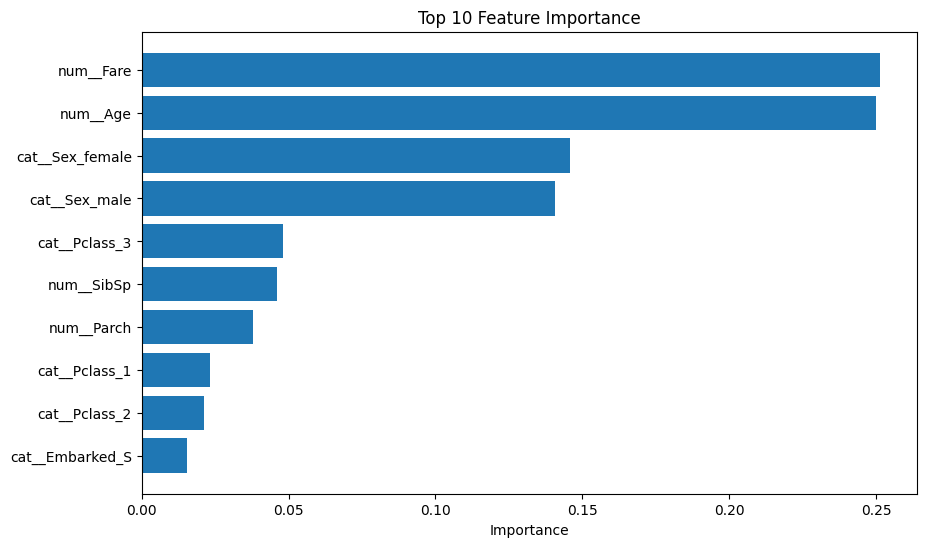

In [25]:
# 21. Plot Feature Importance
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.title("Top 10 Feature Importance")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

In [26]:
# 22. Predict on New Passenger
new_passenger = pd.DataFrame({

    "Pclass":[3],

    "Sex":["male"],

    "Age":[25],

    "SibSp":[0],

    "Parch":[0],

    "Fare":[8.05],

    "Embarked":["S"]

})

prediction = model_pipeline.predict(new_passenger)

print("\nPrediction For New Passenger")

if prediction[0] == 1:
    print("Passenger Will Survive")
else:
    print("Passenger Will Not Survive")



Prediction For New Passenger
Passenger Will Not Survive


In [27]:
# 23. Conclusion0
print("""

Conclusion

1. Data preprocessing was automated using sklearn Pipeline.

2. Missing values were handled automatically.

3. Numerical columns were scaled.

4. Categorical columns were encoded.

5. Random Forest Classifier was used.

6. The pipeline is reusable for future prediction.

7. This workflow reduces manual effort and prevents data leakage.

""")



Conclusion

1. Data preprocessing was automated using sklearn Pipeline.

2. Missing values were handled automatically.

3. Numerical columns were scaled.

4. Categorical columns were encoded.

5. Random Forest Classifier was used.

6. The pipeline is reusable for future prediction.

7. This workflow reduces manual effort and prevents data leakage.


